In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
from config import SILVER_DATASET, EDA_DATA_DIR

OUT_FILE = EDA_DATA_DIR / "eda_databridge.csv"

df = pd.read_csv(SILVER_DATASET)

print("Paths configurados ✅")


Paths configurados ✅


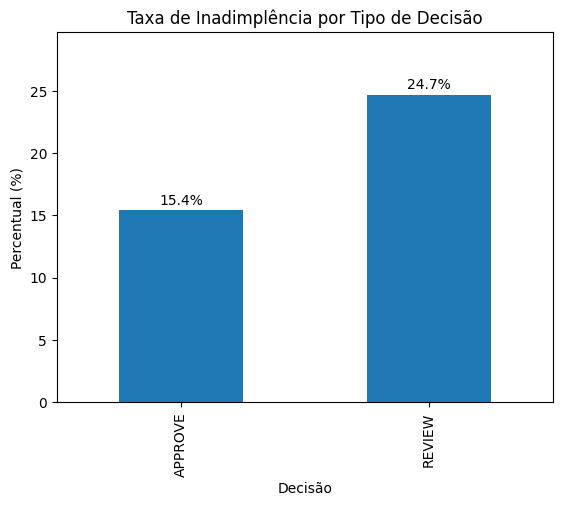

In [15]:
data = df.groupby("final_decision")["default_12m"].mean() * 100
data = data.round(1).sort_values()

ax = data.plot(kind="bar")

for i, v in enumerate(data):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.title("Taxa de Inadimplência por Tipo de Decisão")
plt.ylabel("Percentual (%)")
plt.xlabel("Decisão")
plt.ylim(0, max(data) + 5)

plt.show()

“Casos que vão para revisão apresentam maior risco, indicando que o sistema consegue identificar perfis mais incertos.”

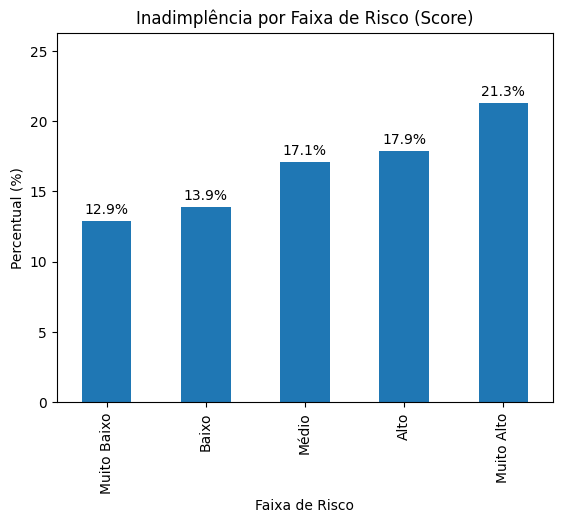

In [16]:
df["pd_range"] = pd.qcut(
    df["pd_model_score"],
    5,
    labels=["Muito Baixo", "Baixo", "Médio", "Alto", "Muito Alto"]
)

data = df.groupby("pd_range")["default_12m"].mean() * 100
data = data.round(1)

ax = data.plot(kind="bar")

for i, v in enumerate(data):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.title("Inadimplência por Faixa de Risco (Score)")
plt.ylabel("Percentual (%)")
plt.xlabel("Faixa de Risco")
plt.ylim(0, max(data) + 5)

plt.show()

“Quanto maior o score de risco, maior a inadimplência — o modelo está consistente.”

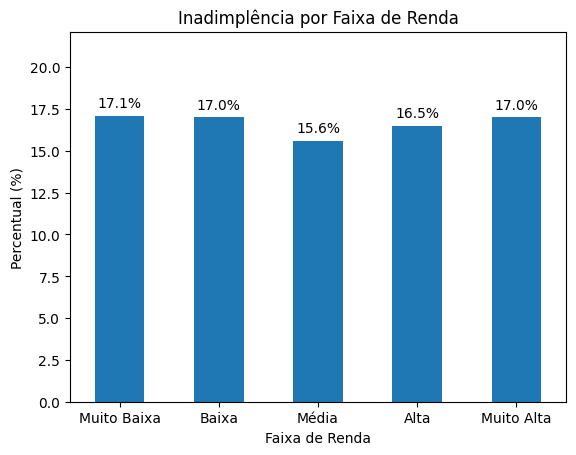

In [17]:
df["income_range"] = pd.qcut(
    df["income_declared"],
    5,
    labels=["Muito Baixa", "Baixa", "Média", "Alta", "Muito Alta"]
)

data = df.groupby("income_range")["default_12m"].mean() * 100
data = data.round(1)

ax = data.plot(kind="bar")

for i, v in enumerate(data):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.title("Inadimplência por Faixa de Renda")
plt.ylabel("Percentual (%)")
plt.xlabel("Faixa de Renda")
plt.ylim(0, max(data) + 5)

plt.xticks(rotation=0)

plt.show()

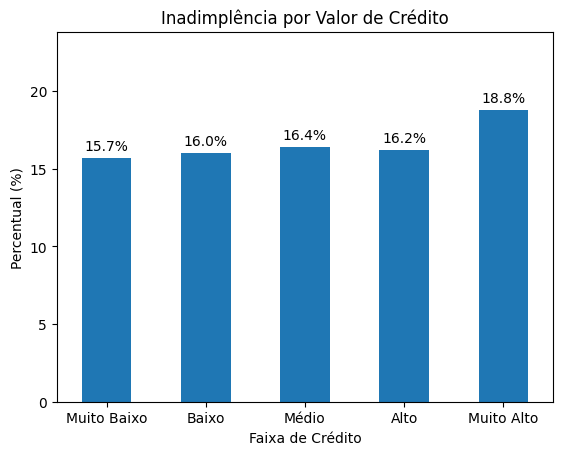

In [18]:
df["credit_range"] = pd.qcut(
    df["credit_requested_value"],
    5,
    labels=["Muito Baixo", "Baixo", "Médio", "Alto", "Muito Alto"]
)

data = df.groupby("credit_range")["default_12m"].mean() * 100
data = data.round(1)

ax = data.plot(kind="bar")

for i, v in enumerate(data):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.title("Inadimplência por Valor de Crédito")
plt.ylabel("Percentual (%)")
plt.xlabel("Faixa de Crédito")
plt.ylim(0, max(data) + 5)

plt.xticks(rotation=0)

plt.show()

In [19]:
df["acerto_aprovacao"] = (
    (df["final_decision"] == "APPROVE") & (df["default_12m"] == 0)
)

In [20]:
df["acerto_aprovacao"] = (
    (df["final_decision"] == "APPROVE") & (df["default_12m"] == 0)
)

In [21]:
## revisar, melhorar (validar melhor dados), matriz de confusao,  análise de variaveis, criar views por 

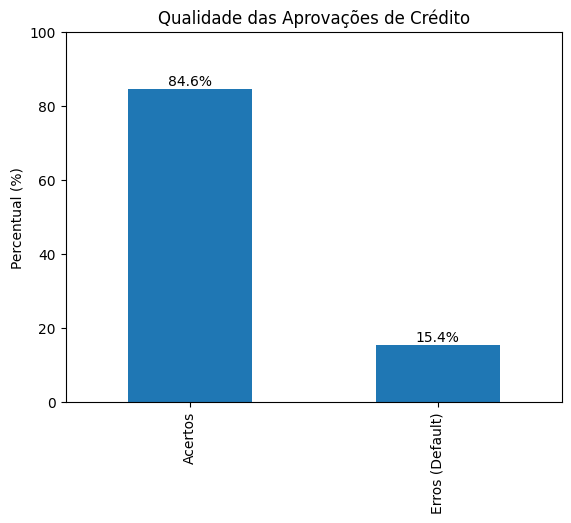

In [22]:
approve_df = df[df["final_decision"] == "APPROVE"]

acertos = (approve_df["default_12m"] == 0).mean() * 100
erros = (approve_df["default_12m"] == 1).mean() * 100

data = pd.Series({
    "Acertos": round(acertos, 1),
    "Erros (Default)": round(erros, 1)
})

ax = data.plot(kind="bar")

for i, v in enumerate(data):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.title("Qualidade das Aprovações de Crédito")
plt.ylabel("Percentual (%)")
plt.ylim(0, 100)

plt.show()

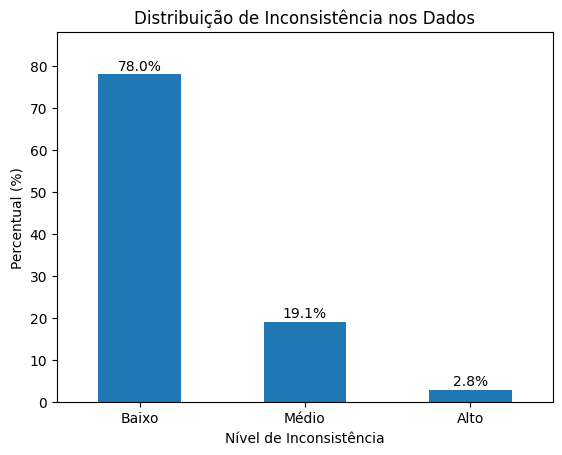

inconsistencia_nivel
Baixo    19490
Médio     4780
Alto       704
Name: count, dtype: int64


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Score base
# =========================
df["inconsistencia_score"] = 0.0


# =========================
# 2. UF vs Região (regra forte)
# =========================
mapa_regiao = {
    "Norte": ["AM", "PA", "AC", "RO", "RR", "AP", "TO"],
    "Nordeste": ["MA", "PI", "CE", "RN", "PB", "PE", "AL", "SE", "BA"],
    "Centro-Oeste": ["MT", "MS", "GO", "DF"],
    "Sudeste": ["SP", "RJ", "MG", "ES"],
    "Sul": ["PR", "SC", "RS"]
}

for regiao, ufs in mapa_regiao.items():
    df.loc[
        (df["regiao"] == regiao) & (~df["uf"].isin(ufs)),
        "inconsistencia_score"
    ] += 1.5   # peso moderado/alto


# =========================
# 3. Data quality (leve)
# =========================
df.loc[
    df["data_quality_score"] < 0.6,
    "inconsistencia_score"
] += 0.5


# =========================
# 4. Documento vs renda (regra forte)
# =========================
df.loc[
    (df["doc_type"] == "RG") &
    (df["income_declared"] > df["income_declared"].quantile(0.80)),
    "inconsistencia_score"
] += 2   # forte


# =========================
# 5. Match score (ajustado)
# =========================
df.loc[
    df["match_score"] < 0.55,
    "inconsistencia_score"
] += 1   # moderado


# =========================
# 6. OCR + imagem (leve)
# =========================
df.loc[
    (df["ocr_confidence"] < 0.5) &
    (df["document_image_quality"] < 0.5),
    "inconsistencia_score"
] += 0.5


# =========================
# 7. Regra combinada (forte)
# =========================
df.loc[
    (df["match_score"] < 0.55) &
    (df["data_quality_score"] < 0.6),
    "inconsistencia_score"
] += 1.5


# =========================
# 8. Classificação final
# =========================
df["inconsistencia_nivel"] = pd.cut(
    df["inconsistencia_score"],
    bins=[-1, 0.5, 1.5, 10],
    labels=["Baixo", "Médio", "Alto"]
)


# =========================
# 9. Distribuição (%)
# =========================
data = df["inconsistencia_nivel"].value_counts(normalize=True) * 100
data = data.round(1)

data = data[["Baixo", "Médio", "Alto"]]


# =========================
# 10. Gráfico
# =========================
ax = data.plot(kind="bar")

for i, v in enumerate(data):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.title("Distribuição de Inconsistência nos Dados")
plt.ylabel("Percentual (%)")
plt.xlabel("Nível de Inconsistência")
plt.ylim(0, max(data) + 10)

plt.xticks(rotation=0)
plt.show()


# =========================
# 11. Volume absoluto
# =========================
print(df["inconsistencia_nivel"].value_counts())

In [24]:
df["inconsistencia_score"].value_counts()

inconsistencia_score
0.0    18874
1.0     4780
3.0      690
0.5      616
3.5       14
Name: count, dtype: int64

In [25]:
df.to_csv(OUT_FILE, index=False)
size_mb = os.path.getsize(OUT_FILE) / 1024 / 1024
print(f"✅ Silver salvo em: {OUT_FILE}")
print(f"   Tamanho        : {size_mb:.2f} MB")
print(f"   Linhas         : {len(df):,}")
print(f"   Colunas        : {df.shape[1]}")

✅ Silver salvo em: C:\Users\Marce\OneDrive\Área de Trabalho\bb_2\data\eda\eda_databridge.csv
   Tamanho        : 5.92 MB
   Linhas         : 24,974
   Colunas        : 43
